In [35]:
from MambaSSLModel import MambaAutoencoderModel, HARMambaConfig, MambaDownstreamClassifier
from data.PAM_data import load_PAM_loco_data, data_split_PAM, make_loaders_PAM
from test_mamba import test_model, save_json 
import json
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from mamba_ssm.modules.mamba2 import Mamba2
import mamba_ssm.modules.mamba2 as mm
from data.preprocessing import fit_labelencoder, Dataset_HAR
from datetime import datetime
import torch.nn.functional as F
import mamba_ssm
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from utils import set_seed
import argparse
from torch.profiler import profile, ProfilerActivity
import time
try:
    from mamba_ssm.ops.triton.layer_norm import RMSNorm, layer_norm_fn, rms_norm_fn
except ImportError:
    RMSNorm, layer_norm_fn, rms_norm_fn = None, None, None
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import math
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import random
import colorsys

In [36]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

In [37]:
configs = {
    #"Encoder congelado (Span Masking)": "/home/kmercad/mamba_har/SELFSUPERVISED_MAMBA_PAM/SSL_ENCODER_CE_ALG1/results_json",
    #"Fine-tuning completo (Span Masking)":  "/home/kmercad/mamba_har/SELFSUPERVISED_MAMBA_PAM/SSL_FF_CE_ALG1/results_json", 
    "Encoder congelado (Device Masking)": "/home/kmercad/mamba_har/SELFSUPERVISED_MAMBA_PAM/SSL_ENCODER_CE_ALG2/results_json",
    #"Fine-tuning completo (Device Masking)":  "/home/kmercad/mamba_har/SELFSUPERVISED_MAMBA_PAM/results_json",
    #"Fine-tuning completo WCE":  "/home/kmercad/mamba_har/SELFSUPERVISED_MAMBA/results_json",
}

dataset_name = "PAM"
n_folds = 4

In [38]:
def load_folds_results(base_dir, dataset_name, n_folds=4):
    all_folds = {} 
    for fold_idx in range(1, n_folds + 1):
        json_path = Path(base_dir) / f"{dataset_name}_fold{fold_idx}_results.json"
        
        with open(json_path, "r") as f:
            all_folds[fold_idx] = json.load(f)
    
    return all_folds

In [39]:
def summarize_fold(results):
    runs = results["runs"]
    f1_scores = [seed_data["summary"]["test_f1"] for seed_data in runs.values()]
    
    mean_f1 = np.mean(f1_scores)
    std_f1 = np.std(f1_scores)
    
    return mean_f1, std_f1

In [40]:
def build_config_row(base_dir, config_name, dataset_name="PAM", n_folds=4):
    all_folds = load_folds_results(base_dir, dataset_name, n_folds) 
    row = {"Configuración": config_name}
    split_means = []
    
    for fold_idx in range(1, n_folds + 1):
        mean_f1, std_f1 = summarize_fold(all_folds[fold_idx])
        row[f"Split {fold_idx}"] = f"{mean_f1:.3f} ± {std_f1:.3f}"
        split_means.append(mean_f1)
    
    row["Media ± std"] = f"{np.mean(split_means):.3f} ± {np.std(split_means):.3f}"
    
    return row

In [41]:
rows = []
for config_name, base_dir in configs.items():
    rows.append(build_config_row(base_dir, config_name, dataset_name, n_folds))

summary_df = pd.DataFrame(rows)
#display(summary_df)

In [42]:
styled_df = (
    summary_df.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center","font-size": "12pt"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"),
                                     ("font-size", "12pt"),
                                     ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "8px")]}]))

display(styled_df)

Configuración,Split 1,Split 2,Split 3,Split 4,Media ± std
Encoder congelado (Device Masking),0.767 ± 0.051,0.854 ± 0.059,0.775 ± 0.031,0.873 ± 0.029,0.817 ± 0.047


# 4.2.2

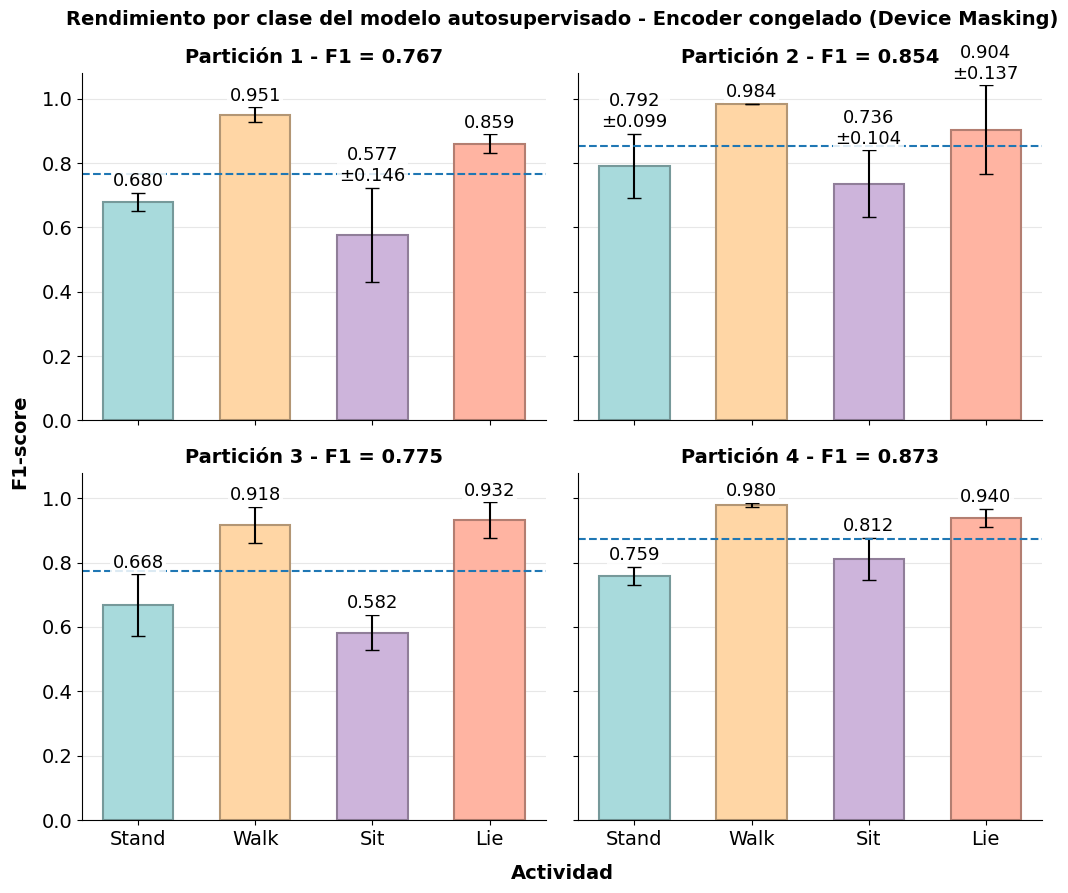

In [43]:
# FOR THESIS — F1-score per class by split
colors = ["#A8DADC", "#FFD6A5", "#CDB4DB", "#FFB4A2"]
classes = ["Stand", "Walk", "Sit", "Lie"]

def darken(color, factor): 
    r, g, b = mcolors.to_rgb(color)
    return (r * factor, g * factor, b * factor)

def per_class_f1_from_cm(cm):
    cm = np.asarray(cm, dtype=float)
    tp = np.diag(cm)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp), where=(tp + fn) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) != 0)
    return f1

for config_name, base_dir in configs.items():
    all_folds = load_folds_results(base_dir, dataset_name, n_folds)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True, sharex=True)
    fig.suptitle(f"Rendimiento por clase del modelo autosupervisado - {config_name}", fontweight="bold", fontsize=14) 

    axes = axes.ravel()
    edge_colors = [darken(c, 0.7) for c in colors]

    for idx, fold_idx in enumerate(range(1, n_folds + 1)):
        seed_f1_scores = np.array([per_class_f1_from_cm(s["summary"]["test_conf_matrix"]) for s in all_folds[fold_idx]["runs"].values()])
        mean_f1 = seed_f1_scores.mean(axis=0)
        std_f1 = seed_f1_scores.std(axis=0)
        order = [2, 3, 1, 0]  # datos en orden PAM [LIE,SIT,STAND,WALK] -> display orden OPP [Stand,Walk,Sit,Lie]
        mean_f1 = mean_f1[order]
        std_f1 = std_f1[order]
        avg_f1 = mean_f1.mean()

        bars = axes[idx].bar(classes, mean_f1, yerr=std_f1, width=0.6, capsize=5, color=colors, linewidth=0.8)

        for bar, ec in zip(bars, edge_colors):
            bar.set_edgecolor(ec)
            bar.set_linewidth(1.5)

        axes[idx].axhline(avg_f1, linestyle="--", linewidth=1.5)

        #for bar, val, err in zip(bars, mean_f1, std_f1):
        for i, (bar, val, err) in enumerate(zip(bars, mean_f1, std_f1)):
            label = f"{val:.3f}\n±{err:.3f}" if (i == 0 and fold_idx == 2) or (i == 2 and fold_idx == 2) or (i == 3 and fold_idx == 2) or (i == 2 and fold_idx == 1) else f"{val:.3f}"
            #axes[idx].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + err + 0.008, f"{val:.3f}", ha="center", va="bottom", fontsize=13, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5))
            axes[idx].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + err + 0.008, label, ha="center", va="bottom", fontsize=13, bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5))

        axes[idx].set_title(f"Partición {fold_idx} - F1 = {avg_f1:.3f}", fontweight="bold", fontsize=14, pad=7)
        axes[idx].tick_params(axis="x", rotation=0, labelsize=14)
        axes[idx].tick_params(axis="y", rotation=0, labelsize=14)
        axes[idx].grid(axis="y", alpha=0.3)
        axes[idx].set_axisbelow(True)
        axes[idx].spines["top"].set_visible(False)
        axes[idx].spines["right"].set_visible(False)
        #axes[idx].legend(loc="upper left", bbox_to_anchor=(0.02, 1.1), frameon=True, fontsize=11, borderpad=0.4, labelspacing=0.4)

    axes[0].set_ylim(0.0, 1.08)

    fig.supylabel("F1-score", fontweight="bold", fontsize=14, x=0.04)
    fig.supxlabel("Actividad", fontweight="bold", fontsize=14)
    fig.subplots_adjust(left=0.10, right=0.9, top=0.91, bottom=0.08, hspace=0.15, wspace=0.07)

    fname = config_name.replace(" ", "_").replace("+", "plus")
    #fig.savefig(f"f1_per_class_{fname}_PAM.png", dpi=600, bbox_inches="tight")
    plt.show()

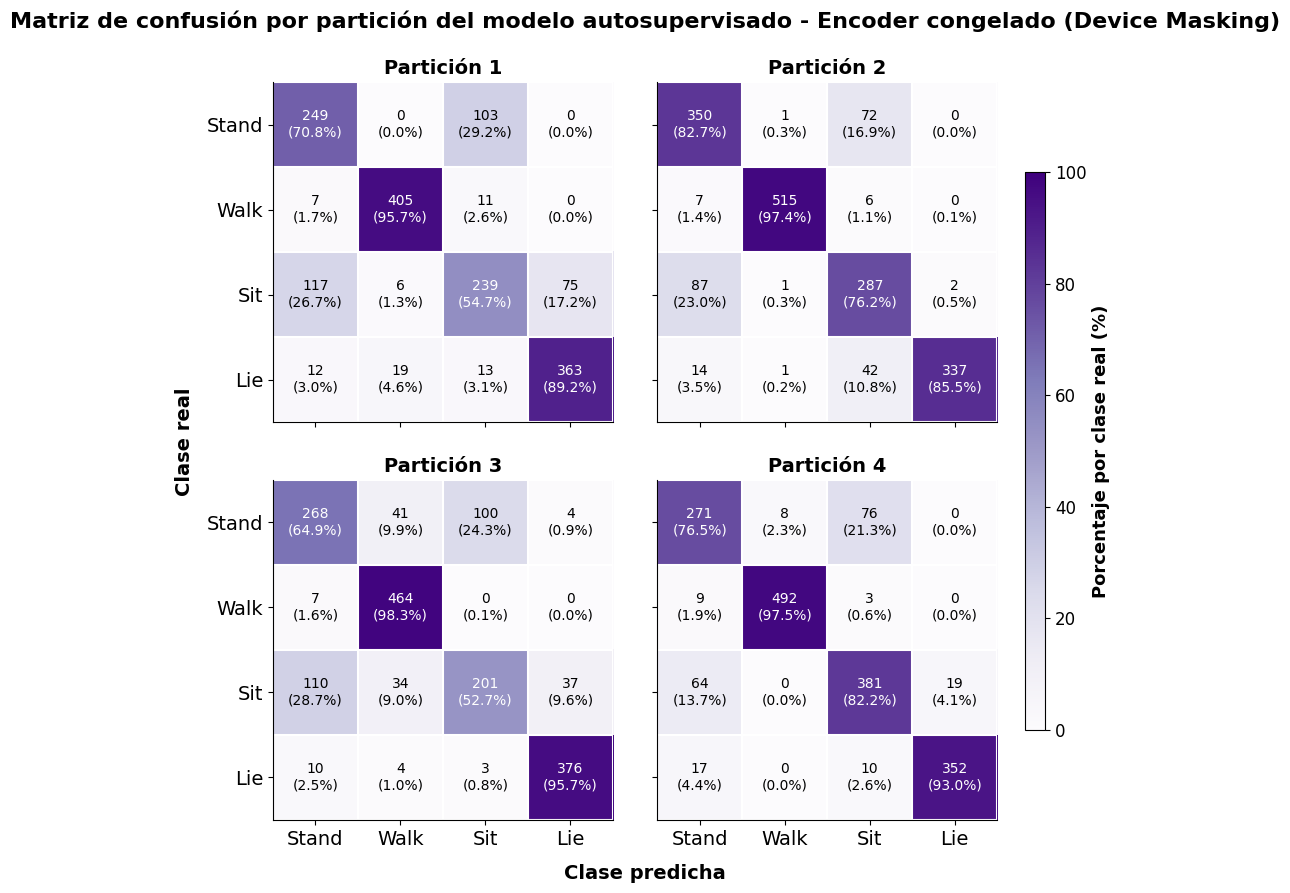

In [45]:
# FOR THESIS — Average confusion matrix by split

classes = ["Stand", "Walk", "Sit", "Lie"]

def mean_confusion_matrix_for_split(fold_results):
    conf_matrices = [np.array(seed_data["summary"]["test_conf_matrix"], dtype=float) for seed_data in fold_results["runs"].values()]
    return np.mean(conf_matrices, axis=0)

for config_name, base_dir in configs.items():
    all_folds = load_folds_results(base_dir, dataset_name, n_folds)

    fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
    fig.suptitle(f"Matriz de confusión por partición del modelo autosupervisado - {config_name}", fontweight="bold", fontsize=16) 

    axes = axes.ravel()

    for idx, fold_idx in enumerate(range(1, n_folds + 1)):
        mean_cm = mean_confusion_matrix_for_split(all_folds[fold_idx])
        order = [2, 3, 1, 0]  # datos en orden PAM [LIE,SIT,STAND,WALK] -> display orden OPP [Stand,Walk,Sit,Lie]
        mean_cm = mean_cm[np.ix_(order, order)]
        row_sums = mean_cm.sum(axis=1, keepdims=True)
        cm_pct = np.divide(mean_cm, row_sums, out=np.zeros_like(mean_cm), where=row_sums != 0) * 100

        im = axes[idx].imshow(cm_pct, vmin=0, vmax=100, cmap="Purples")

        axes[idx].set_xticks(np.arange(len(classes)))
        axes[idx].set_yticks(np.arange(len(classes)))
        axes[idx].set_xticklabels(classes, fontsize=14)
        axes[idx].set_yticklabels(classes, fontsize=14)
        axes[idx].tick_params(axis="x", rotation=0, labelsize=14)
        axes[idx].tick_params(axis="y", rotation=0, labelsize=14)
        axes[idx].set_title(f"Partición {fold_idx}", fontweight="bold", fontsize=14)

        for i in range(len(classes)):
            for j in range(len(classes)):
                label = f"{mean_cm[i, j]:.0f}\n({cm_pct[i, j]:.1f}%)"
                text_color = "white" if cm_pct[i, j] > 50 else "black"
                axes[idx].text(j, i, label, ha="center", va="center", fontsize=10, color=text_color)

        axes[idx].set_xticks(np.arange(-0.5, len(classes), 1), minor=True)
        axes[idx].set_yticks(np.arange(-0.5, len(classes), 1), minor=True)
        axes[idx].grid(which="minor", color="white", linestyle="-", linewidth=1.5)
        axes[idx].tick_params(which="minor", bottom=False, left=False)
        axes[idx].spines["top"].set_visible(False)
        axes[idx].spines["right"].set_visible(False)

    fig.supylabel("Clase real", fontweight="bold", fontsize=14, x=0.03)
    fig.supxlabel("Clase predicha", fontweight="bold", fontsize=14)
    
    fig.subplots_adjust(left=0.12, right=0.86, top=0.90, bottom=0.08, hspace=0.17, wspace=0.08)
    
    cbar_ax = fig.add_axes([0.88, 0.18, 0.02, 0.62])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("Porcentaje por clase real (%)", fontsize=13, fontweight="bold")
    cbar.ax.tick_params(labelsize=12)
    
    fname = config_name.replace(" ", "_").replace("+", "plus")
    #fig.savefig(f"cm_grid_{fname}_PAM.png", dpi=600, bbox_inches="tight")
    plt.show()

# CALIDAD DE RECONSTRUCCION (SpanMasking)

In [11]:
def load_pretrained_encoder(model, device, fold, seed):
    checkpoint_path = f"SSL_PRETRAIN_ALG1/SSL_models_pt/SSL_model_lr6e4_PAM_fold{fold}_seed{seed}.pt"
    state = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state, strict=True)
    return checkpoint_path

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = HARMambaConfig()
model = MambaAutoencoderModel(config)
model.to(device, non_blocking = True) 
load_pretrained_encoder(model, device, 1, 42)

'SSL_PRETRAIN_ALG1/SSL_models_pt/SSL_model_lr6e4_PAM_fold1_seed42.pt'

In [13]:

training_files, validation_files, test_files = data_split_PAM(1)
X_windows, y_windows, X_validation_windows, y_validation_windows, X_test_windows, y_test_windows = load_PAM_loco_data(training_files, validation_files, test_files, verbose = True)

------------------------------------------------------------------------------------------
Sensor subset training shape: (402331, 29)
Sensor Validation training shape: (205551, 29)
Sensor Test training shape: (198521, 29)
----------------------------------------------------------------------
Rows containing NaNs - training: 5501
Rows containing NaNs - validation: 2883
Rows containing NaNs - test: 2391
------------------------------------------------------------------------------------------
Reindexed training shape: (402331, 29)
Reindexed validation shape: (205551, 29)
Reindexed test shape: (198521, 29)
------------------------------------------------------------------------------------------
After Interpolation. Training shape: (402169, 29)
After Interpolation. Validation shape: (205551, 29)
After Interpolation. Test shape: (198521, 29)


Descriptive statistics for ACC channels (DEVICE_1) - training set
                   0              1              2
count  402169.000000  402169.00

In [14]:



g = set_seed(42)
train_loader, val_loader, test_loader, label_encoder = make_loaders_PAM(X_windows, y_windows, X_validation_windows, y_validation_windows, X_test_windows, y_test_windows, generator = g, verbose = True)

------------------------------------------------------------------------------------------
Training set class distribution:--
{'LIE': 801, 'SIT': 708, 'STAND': 812, 'WALK': 1016}
------------------------------------------------------------------------------------------


In [15]:
FOLD = 1
SEED = 42

TARGET_ACTIVITIES = ["Walk", "Stand", "Sit", "Lie"]

MASK_RATIO = 0.15
LSPAN = 5

MAX_BATCHES_TO_SCAN = 80
TRIES_PER_WINDOW = 5


PAM_loco_map = {
    0: "Lie",
    1: "Sit",
    2: "Stand",
    3: "Walk",
}

def masking_span_algorithm(X_windows, mask_ratio: float, Lspan: int, generator = None)-> [torch.Tensor, torch.Tensor] :
    
    #Span masking Lspan 5 considering 0.
    #avoiding mismatch with 80/20 trick.
    
    B, Lw, Ft =  X_windows.shape
    target = round(Lw * mask_ratio)
    #create empty mask
    mask = torch.zeros((B, Lw), dtype=torch.bool, device=X_windows.device)
    mask_zero = torch.zeros((B, Lw), dtype=torch.bool, device=X_windows.device)
    for b in range(B):
        I = set()
        counter = 0  
        candidates = set()
        
        while counter < target:
            remaining = target - counter
            l = min(Lspan, remaining)
        
            found_valid_chunk = False
            while not found_valid_chunk:
                sample = torch.randint(0, Lw-l+1, (1,), generator = generator).item() #sample rnd value
                candidates = set(range(sample, sample + l)) # create candidates
                if not(candidates & I):
                    found_valid_chunk = True
            
            I.update(candidates) # create idx for that window
            counter = counter + l
        
        # here add 80/20 to avoid mismatch.
        mask[b, list(I)] = True # need ALL the masked values for the loss.
        if np.random.rand() < 0.8:
            mask_zero[b, list(I)] = True
        
    X_masked = X_windows.clone()  
    X_masked[mask_zero] = 0

    return mask, X_masked


def label_to_activity(lbl):
    """
    Convierte el label del loader a nombre de actividad.
    Funciona tanto si y_batch viene encoded como 0,1,2,3
    como si viene con labels originales 1,2,4,5.
    """
    lbl = int(lbl)

    # Caso labels originales: 1,2,4,5
    if lbl in PAM_loco_map:
        return PAM_loco_map[lbl]

    # Caso labels encoded: 0,1,2,3
    if 0 <= lbl < len(label_encoder.classes_):
        raw = label_encoder.classes_[lbl]

        try:
            raw_int = int(raw)
            return PAM_loco_map.get(raw_int, str(raw))
        except Exception:
            return str(raw).strip().title()

    return str(lbl)


def masking_span_for_figure(X_windows, mask_ratio=0.15, Lspan=5, generator=None):
    """
    Máscara Span para visualización.

    Diferencia con la de entrenamiento:
    aquí ponemos a cero TODAS las posiciones de la máscara,
    para que la máscara sea visible en la figura.
    """
    B, Lw, Ft = X_windows.shape

    target = max(1, int(round(Lw * mask_ratio)))

    mask = torch.zeros((B, Lw), dtype=torch.bool, device=X_windows.device)

    for b in range(B):
        used = set()

        while len(used) < target:
            remaining = target - len(used)
            l = min(Lspan, remaining)

            valid_starts = []

            for s in range(0, Lw - l + 1):
                candidate = set(range(s, s + l))

                if not (candidate & used):
                    valid_starts.append(s)

            if len(valid_starts) == 0:
                break

            idx = torch.randint(
                0,
                len(valid_starts),
                (1,),
                generator=generator,
            ).item()

            s = valid_starts[idx]
            used.update(range(s, s + l))

        mask[b, list(used)] = True

    X_masked = X_windows.clone()
    X_masked[mask] = 0

    return mask, X_masked


def visible_score(x_sample, mask):
    """
    Score alto = la zona enmascarada tiene señal visible.
    Evita escoger zonas demasiado planas o casi cero.
    """
    x_np = x_sample.detach().cpu().numpy()
    m_np = mask.detach().cpu().numpy()

    seg = x_np[m_np]

    if seg.size == 0:
        return -np.inf

    variation = np.nanmean(np.std(seg, axis=0))
    magnitude = np.nanmean(np.abs(seg))

    return float(variation + 0.25 * magnitude)


def choose_visible_examples(loader):
    best_examples = {}

    g_mask = torch.Generator().manual_seed(SEED)

    with torch.no_grad():
        for batch_idx, (x_batch, y_batch) in enumerate(loader):
            if batch_idx >= MAX_BATCHES_TO_SCAN:
                break

            for i in range(x_batch.size(0)):
                lbl = int(y_batch[i].item())
                activity = label_to_activity(lbl)

                if activity not in TARGET_ACTIVITIES:
                    continue

                x_sample = x_batch[i].detach().cpu().float()

                for _ in range(TRIES_PER_WINDOW):
                    mask, x_masked = masking_span_for_figure(
                        x_sample.unsqueeze(0),
                        mask_ratio=MASK_RATIO,
                        Lspan=LSPAN,
                        generator=g_mask,
                    )

                    mask = mask.squeeze(0).cpu()
                    x_masked = x_masked.squeeze(0).cpu()

                    score = visible_score(x_sample, mask)

                    if activity not in best_examples or score > best_examples[activity]["score"]:
                        best_examples[activity] = {
                            "label": lbl,
                            "activity": activity,
                            "x": x_sample,
                            "x_masked": x_masked,
                            "mask": mask,
                            "score": score,
                            "batch_idx": batch_idx,
                            "idx_in_batch": i,
                        }

    return best_examples


class_examples = choose_visible_examples(test_loader)

print("Ejemplos elegidos con máscara visible:")
for activity in TARGET_ACTIVITIES:
    ex = class_examples.get(activity)

    if ex is None:
        print(f"{activity:8s}: NO encontrado")
    else:
        print(
            f"{activity:8s}: shape={tuple(ex['x'].shape)}, "
            f"batch={ex['batch_idx']}, idx={ex['idx_in_batch']}, "
            f"score={ex['score']:.4f}"
        )


Ejemplos elegidos con máscara visible:
Walk    : shape=(160, 27), batch=10, idx=35, score=1.6101
Stand   : shape=(160, 27), batch=6, idx=48, score=0.6516
Sit     : shape=(160, 27), batch=17, idx=2, score=1.0276
Lie     : shape=(160, 27), batch=0, idx=4, score=1.2662


In [16]:
def extract_reconstruction(model_output):
    """
    Por si el modelo devuelve tensor, tuple/list o dict.
    En tu caso parece que devuelve tensor directo, pero esto lo hace más seguro.
    """
    if torch.is_tensor(model_output):
        return model_output

    if isinstance(model_output, (tuple, list)):
        for item in model_output:
            if torch.is_tensor(item):
                return item

    if isinstance(model_output, dict):
        for key in ["reconstruction", "recon", "x_hat", "x_recon", "output"]:
            if key in model_output and torch.is_tensor(model_output[key]):
                return model_output[key]

        for value in model_output.values():
            if torch.is_tensor(value):
                return value

    raise ValueError("No pude extraer la reconstrucción del output del modelo.")


recon_results = {}

model.eval()

with torch.no_grad():
    for activity, ex in class_examples.items():
        x_orig = ex["x"]
        x_masked = ex["x_masked"]
        mask = ex["mask"]

        x_masked_b = x_masked.unsqueeze(0).to(device)

        output = model(x_masked_b)
        x_hat = extract_reconstruction(output)

        x_hat = x_hat.squeeze(0).detach().cpu()

        recon_results[activity] = {
            "original": x_orig.numpy(),
            "masked": x_masked.numpy(),
            "reconstructed": x_hat.numpy(),
            "mask": mask.numpy(),
        }


print(f"MSE en posiciones enmascaradas - Span Masking, fold={FOLD}, seed={SEED}:")

for activity in TARGET_ACTIVITIES:
    r = recon_results[activity]

    m = r["mask"]

    mse = np.mean(
        (r["original"][m] - r["reconstructed"][m]) ** 2
    )

    print(f"{activity:8s}: MSE = {mse:.6f}")

MSE en posiciones enmascaradas - Span Masking, fold=1, seed=42:
Walk    : MSE = 1.589278
Stand   : MSE = 0.152232
Sit     : MSE = 0.705908
Lie     : MSE = 0.696967


In [17]:
colors = ["#B8D4EC", "#FFD6A5", "#A8D5A2", "#FFB4A2"]

import colorsys

def vivify(color, sat=1.8, light=0.65):
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    return colorsys.hls_to_rgb(h, min(1, l * light), min(1, s * sat))

line_colors = [vivify(c) for c in colors[:3]]

def mask_runs(mask):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return []
    runs  = []
    start = idx[0]
    prev  = idx[0]
    for v in idx[1:]:
        if v == prev + 1:
            prev = v
        else:
            runs.append((start, prev + 1))
            start = v
            prev  = v
    runs.append((start, prev + 1))
    return runs

device_names = ["IMU_1", "IMU_2", "IMU_3"]

modalities = {
    "Acelerómetro":  [0, 1, 2],
    "Giroscopio": [3, 4, 5],
    "Magnetómetro":  [6, 7, 8],
}

def plot_reconstruction(activity):
    r             = recon_results[activity]
    original      = np.asarray(r["original"])
    masked        = np.asarray(r["masked"])
    reconstructed = np.asarray(r["reconstructed"])
    mask          = np.asarray(r["mask"]).astype(bool)

    # 1) Escoge UN dispositivo/IMU completo
    device_scores = []
    for device_idx in range(3):
        start_ch = device_idx * 9
        score    = np.var(original[mask, start_ch:start_ch + 9])
        device_scores.append(score)

    device_idx  = int(np.argmax(device_scores))
    device_name = device_names[device_idx]
    start_ch    = device_idx * 9

    # 2) Dentro de ese MISMO dispositivo, escoge un canal de ACC, GYRO y MAG
    selected = []
    for modality_name, local_idxs in modalities.items():
        global_idxs = [start_ch + i for i in local_idxs]
        scores      = [np.var(original[mask, ch]) for ch in global_idxs]
        best_ch     = global_idxs[int(np.argmax(scores))]
        selected.append((modality_name, best_ch))

    t = np.arange(original.shape[0]) / 33.3
  
    # MSE del dispositivo completo, no solo de los 3 canales dibujados
    mse = np.mean(
        (original[mask, start_ch:start_ch + 9] - reconstructed[mask, start_ch:start_ch + 9]) ** 2
    )

    fig, axes = plt.subplots(3, 1, figsize=(14, 9.6), sharex=True)
    fig.suptitle(
        f"{activity} (Span Masking)", #|MSE = {mse:.4f}|{device_name} IMU
        fontweight="bold", fontsize=14
    )

    for i, (ax, (modality_name, ch)) in enumerate(zip(axes, selected)):
        ax.plot(t, original[:, ch], color=line_colors[0], lw=2.1, label="Original")
        ax.plot(t, masked[:, ch], color=line_colors[1], lw=2.5, linestyle=":",  alpha=0.85, label="Entrada con máscara")
        ax.plot(t, reconstructed[:, ch], color=line_colors[2], lw=2.1, linestyle="--", label="Reconstruida")

        for s, e in mask_runs(mask):
            ax.axvspan(s / 33.3, e / 33.3, alpha=0.18, color="gray", lw=0)
  
        ax.set_ylabel(modality_name, fontweight="bold", fontsize=14)
        ax.tick_params(axis="x", rotation=0, labelsize=14)
        ax.tick_params(axis="y", rotation=0, labelsize=14)
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if i == 0:
            legend_loc = "lower right" if activity == "Lie" else "upper right"
            ax.legend(loc=legend_loc, frameon=True, fontsize=11, borderpad=0.4, labelspacing=0.4)

    fig.supylabel("Valor estandarizado", fontweight="bold", fontsize=14, x=0.01)
    fig.supxlabel("Tiempo (s)", fontweight="bold", fontsize=14)
    fig.subplots_adjust(left=0.09, right=0.97, top=0.91, bottom=0.07, hspace=0.18)
    fig.savefig(f"reconstruction_{activity}_PAM.png", dpi=600, bbox_inches="tight")
    plt.show()


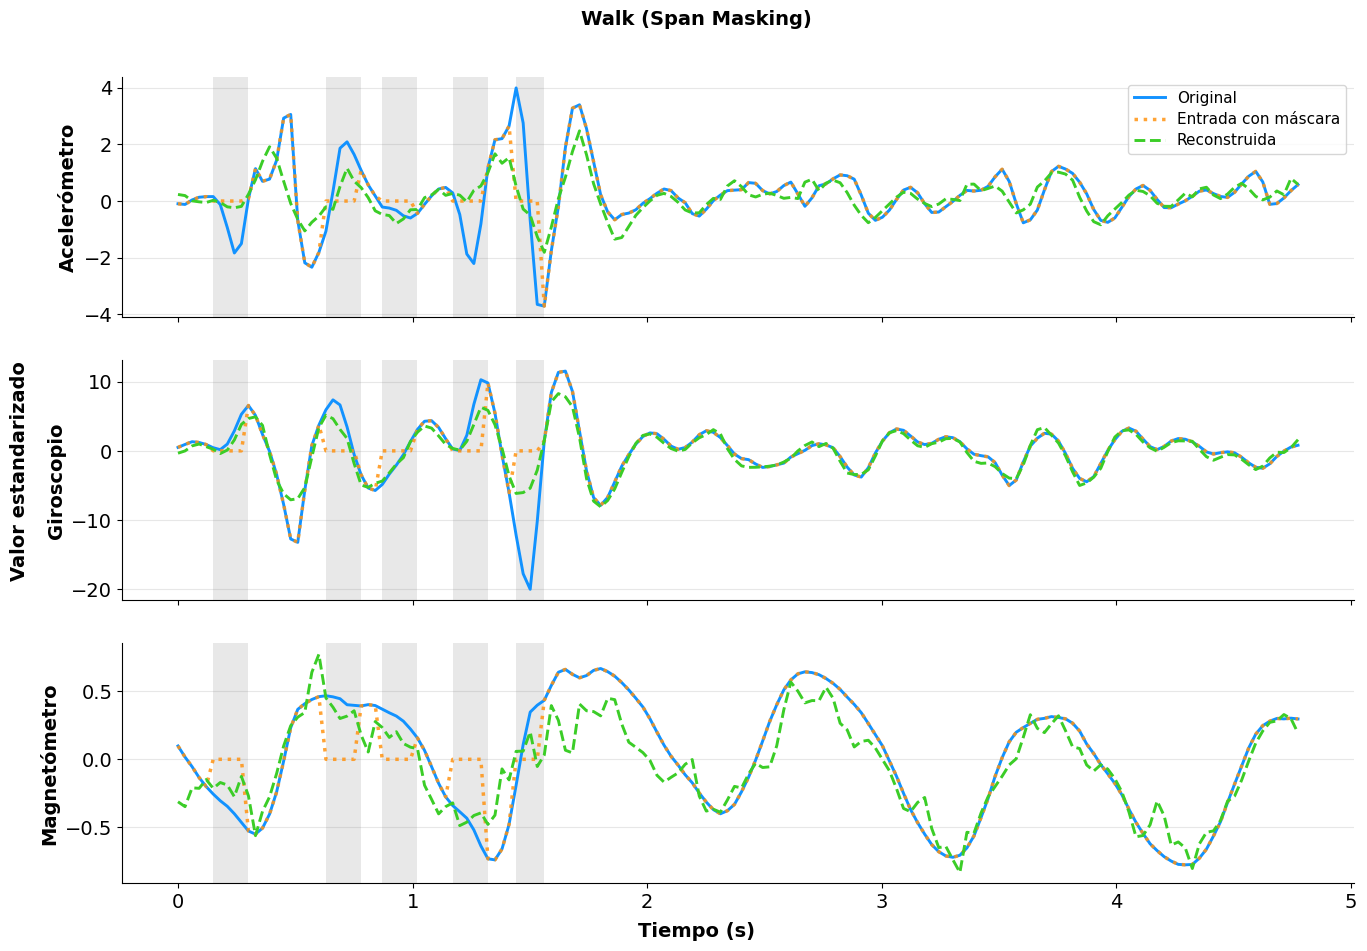

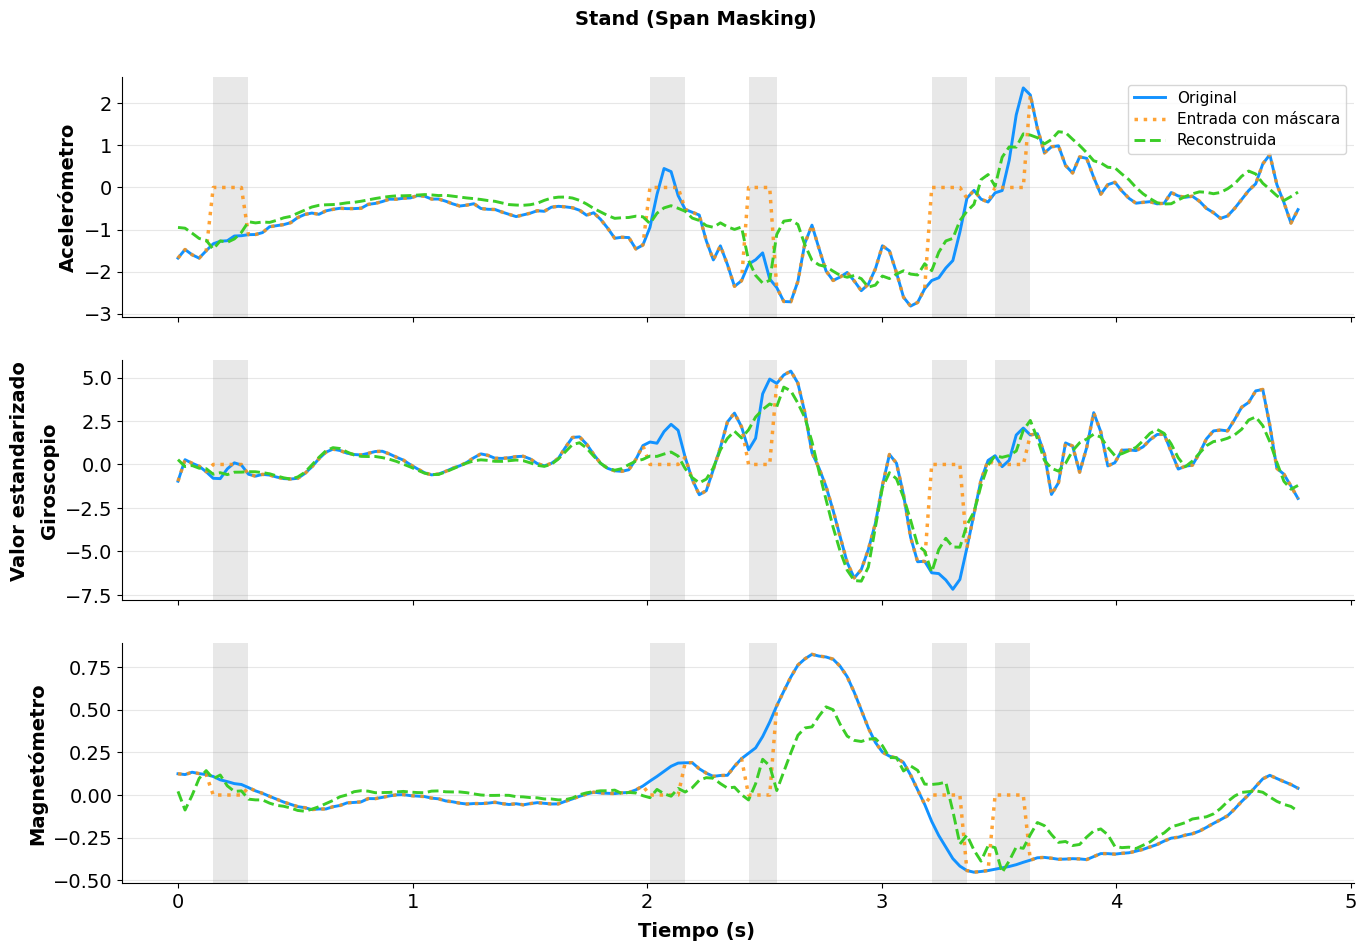

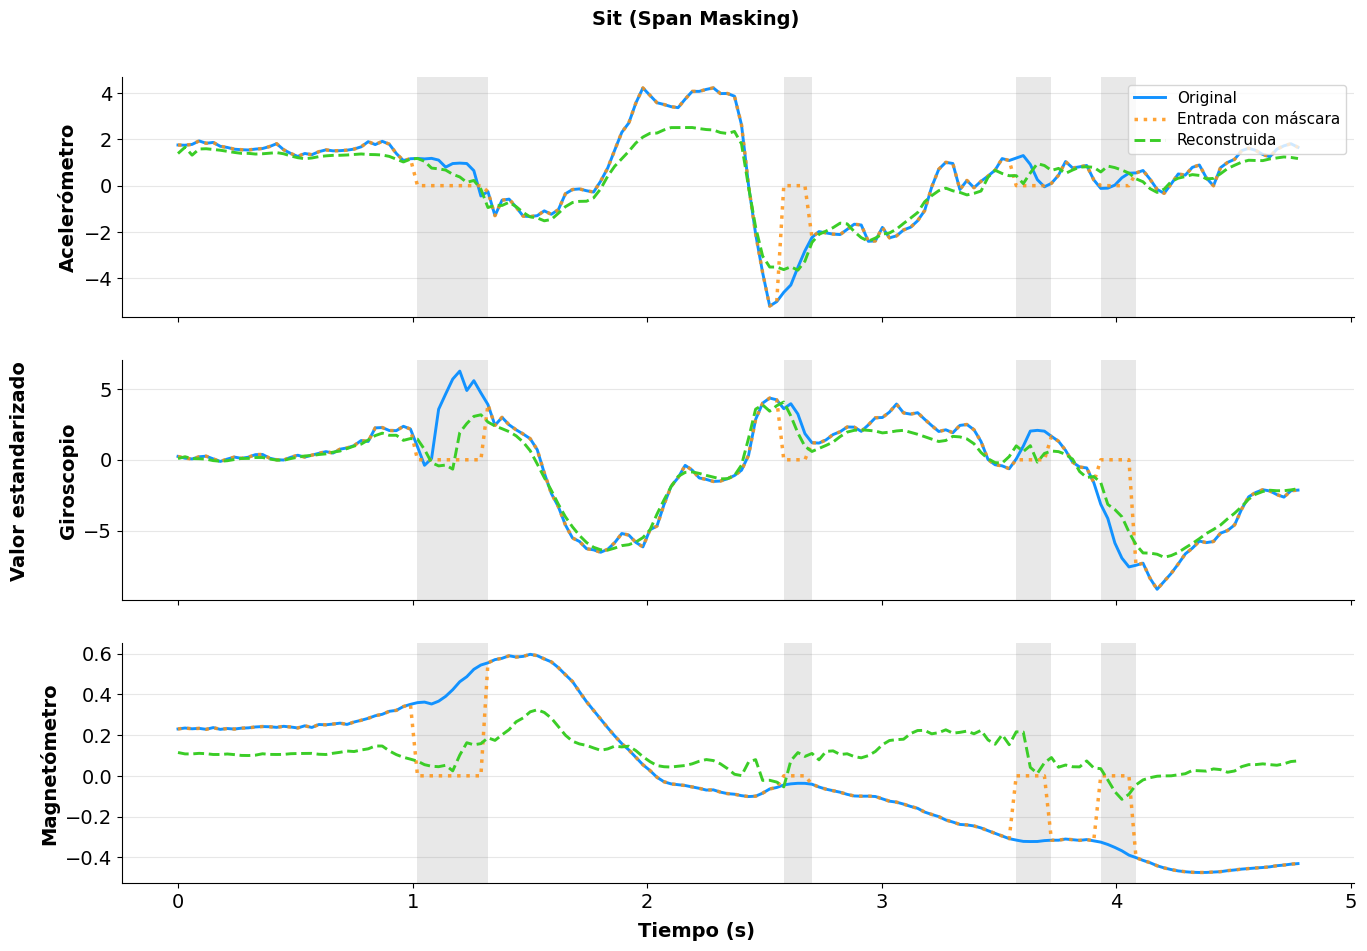

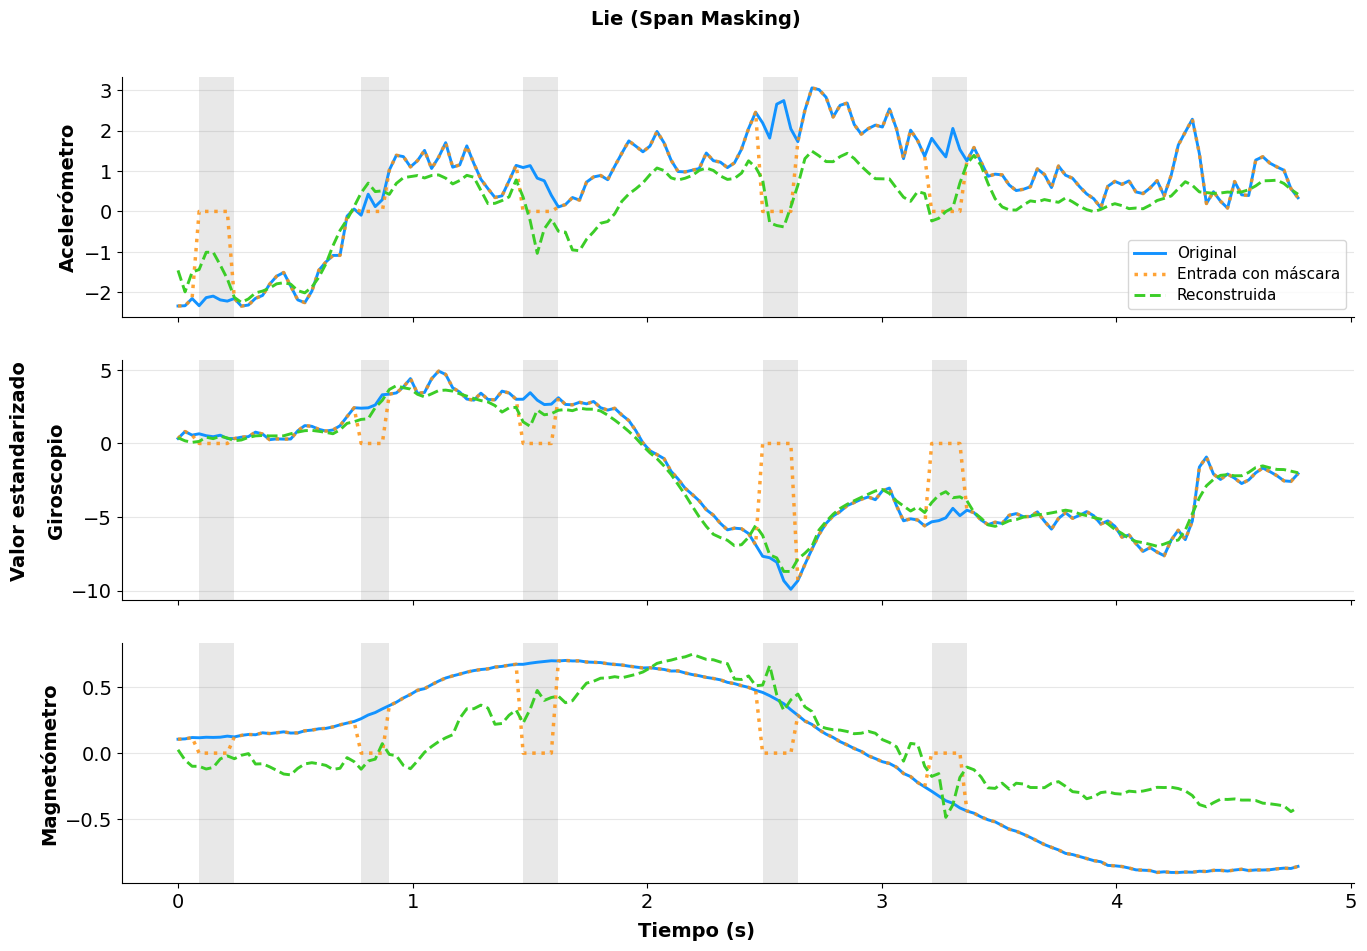

In [18]:
for activity in TARGET_ACTIVITIES:
    plot_reconstruction(activity)

# CALIDAD DE RECONSTRUCCION (DeviceMasking)

In [28]:
def load_pretrained_encoder(model, device, fold, seed):
    checkpoint_path = f"SSL_models_pt/SSL_model_lr6e4_PAM_fold{fold}_seed{seed}.pt"
    state = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state, strict=True)
    return checkpoint_path

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = HARMambaConfig()
model = MambaAutoencoderModel(config)
model.to(device, non_blocking = True) 
load_pretrained_encoder(model, device, 1, 42)

'SSL_models_pt/SSL_model_lr6e4_PAM_fold1_seed42.pt'

In [30]:

training_files, validation_files, test_files = data_split_PAM(1)
X_windows, y_windows, X_validation_windows, y_validation_windows, X_test_windows, y_test_windows = load_PAM_loco_data(training_files, validation_files, test_files, verbose = False)

--------------------STRATIY VAL/TEST--------------------
Validation GROUPS
group_id
102    103884
104    105177
Name: count, dtype: int64
Test GROUPS
group_id
101     94637
103    100374
Name: count, dtype: int64 


 Validation Split Label Proportion
27
1.0    0.222313
2.0    0.228818
3.0    0.240514
4.0    0.308355
Name: proportion, dtype: float64
Test Split Label Proportion
27
1.0    0.252452
2.0    0.267887
3.0    0.216654
4.0    0.263006
Name: proportion, dtype: float64


In [31]:


g = set_seed(42)
train_loader, val_loader, test_loader, label_encoder = make_loaders_PAM(X_windows, y_windows, X_validation_windows, y_validation_windows, X_test_windows, y_test_windows, generator = g, verbose = True)

------------------------------------------------------------------------------------------
Training set class distribution:--
{'LIE': 801, 'SIT': 708, 'STAND': 812, 'WALK': 1016}
------------------------------------------------------------------------------------------


In [32]:
import random
import numpy as np
import torch

FOLD = 1
SEED = 42

TARGET_ACTIVITIES = ["Walk", "Stand", "Sit", "Lie"]

MAX_BATCHES_TO_SCAN = 80
TRIES_PER_WINDOW = 5
CHANNELS_PER_DEVICE = 9

DEVICE_NAMES = ["IMU_1", "IMU_2", "IMU_3"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


PAM_loco_map = {
    0: "Lie",
    1: "Sit",
    2: "Stand",
    3: "Walk",
}


def device_masking_algorithm(X_windows)-> [torch.Tensor, torch.Tensor] :
    B, Lw, Ft =  X_windows.shape
    #create empty mask
    mask = torch.zeros((B, Lw, Ft), dtype=torch.bool, device=X_windows.device)
    mask_zero = torch.zeros((B, Lw, Ft), dtype=torch.bool, device=X_windows.device)
    for b in range(B):
        I = set()
        device_idx = random.randint(0, 2)
        cols = range(device_idx*9, device_idx*9+9) #select device
        I.update(cols)

        # here add 80/20 to avoid mismatch.
        mask[b, :, list(I)] = True # need ALL the masked values for the loss.
        if np.random.rand() < 0.8:
            mask_zero[b, :, list(I)] = True

    X_masked = X_windows.clone()
    X_masked[mask_zero] = 0

    return mask, X_masked


def label_to_activity(lbl):
    """
    El DataLoader devuelve labels encoded: 0, 1, 2, 3.
    """
    return PAM_loco_map[int(lbl)]


def get_masked_device_from_mask(mask):
    """
    Devuelve el dispositivo que ha sido seleccionado por Device Masking.
    mask tiene shape [160, 27].
    """
    m_np = mask.detach().cpu().numpy().astype(bool)

    cols = np.where(m_np.any(axis=0))[0]

    if len(cols) == 0:
        return None, None

    device_idx = int(cols[0] // CHANNELS_PER_DEVICE)
    device_name = DEVICE_NAMES[device_idx]

    return device_idx, device_name


def is_real_zero_mask(x_masked, mask):
    """
    Como tu algoritmo tiene 80/20, a veces la máscara existe para la loss,
    pero NO se pone realmente a cero.

    Para las figuras queremos quedarnos solo con casos donde el dispositivo
    seleccionado sí está realmente puesto a cero.
    """
    return torch.all(x_masked[mask] == 0).item()


def visible_score_device(x_sample, mask):
    """
    Score alto = el dispositivo enmascarado tiene señal visible.
    Evita escoger dispositivos/ventanas demasiado planos.
    """
    x_np = x_sample.detach().cpu().numpy()
    m_np = mask.detach().cpu().numpy().astype(bool)

    # En Device Masking, la máscara es [tiempo, canales].
    # Sacamos los canales del dispositivo seleccionado.
    cols = np.where(m_np.any(axis=0))[0]

    if len(cols) == 0:
        return -np.inf

    seg = x_np[:, cols]  

    variation = np.nanmean(np.std(seg, axis=0))
    magnitude = np.nanmean(np.abs(seg))

    return float(variation + 0.25 * magnitude)


def choose_visible_examples(loader):
    best_examples = {}

    with torch.no_grad():
        for batch_idx, (x_batch, y_batch) in enumerate(loader):
            if batch_idx >= MAX_BATCHES_TO_SCAN:
                break

            for i in range(x_batch.size(0)):
                lbl = int(y_batch[i].item())
                activity = label_to_activity(lbl)

                if activity not in TARGET_ACTIVITIES:
                    continue

                x_sample = x_batch[i].detach().cpu().float()

                for _ in range(TRIES_PER_WINDOW):
                    mask, x_masked = device_masking_algorithm(
                        x_sample.unsqueeze(0)
                    )

                    mask = mask.squeeze(0).cpu()
                    x_masked = x_masked.squeeze(0).cpu()

                    # Importante:
                    # si cae en el 20%, la máscara NO se pone a cero.
                    # Para visualización la saltamos.
                    if not is_real_zero_mask(x_masked, mask):
                        continue

                    device_idx, device_name = get_masked_device_from_mask(mask)

                    if device_idx is None:
                        continue

                    score = visible_score_device(x_sample, mask)

                    if activity not in best_examples or score > best_examples[activity]["score"]:
                        best_examples[activity] = {
                            "label": lbl,
                            "activity": activity,
                            "x": x_sample,
                            "x_masked": x_masked,
                            "mask": mask,
                            "device_idx": device_idx,
                            "device_name": device_name,
                            "score": score,
                            "batch_idx": batch_idx,
                            "idx_in_batch": i,
                        }

    return best_examples


class_examples = choose_visible_examples(test_loader)

print("Ejemplos elegidos con máscara visible - Device Masking:")

for activity in TARGET_ACTIVITIES:
    ex = class_examples.get(activity)

    if ex is None:
        print(f"{activity:8s}: NO encontrado")
    else:
        print(
            f"{activity:8s}: shape={tuple(ex['x'].shape)}, "
            f"device={ex['device_name']}, "
            f"batch={ex['batch_idx']}, idx={ex['idx_in_batch']}, "
            f"score={ex['score']:.4f}"
        )


Ejemplos elegidos con máscara visible - Device Masking:
Walk    : shape=(160, 27), device=IMU_1, batch=10, idx=60, score=2.0042
Stand   : shape=(160, 27), device=IMU_1, batch=6, idx=48, score=0.9725
Sit     : shape=(160, 27), device=IMU_2, batch=17, idx=3, score=1.7472
Lie     : shape=(160, 27), device=IMU_2, batch=13, idx=8, score=1.7430


In [33]:
def extract_reconstruction(model_output):
    """
    Por si el modelo devuelve tensor, tuple/list o dict.
    En tu caso parece que devuelve tensor directo, pero esto lo hace más seguro.
    """
    if torch.is_tensor(model_output):
        return model_output

    if isinstance(model_output, (tuple, list)):
        for item in model_output:
            if torch.is_tensor(item):
                return item

    if isinstance(model_output, dict):
        for key in ["reconstruction", "recon", "x_hat", "x_recon", "output"]:
            if key in model_output and torch.is_tensor(model_output[key]):
                return model_output[key]

        for value in model_output.values():
            if torch.is_tensor(value):
                return value

    raise ValueError("No pude extraer la reconstrucción del output del modelo.")


recon_results = {}

model.eval()

with torch.no_grad():
    for activity, ex in class_examples.items():
        x_orig = ex["x"]
        x_masked = ex["x_masked"]
        mask = ex["mask"]

        x_masked_b = x_masked.unsqueeze(0).to(device)

        output = model(x_masked_b)
        x_hat = extract_reconstruction(output)

        x_hat = x_hat.squeeze(0).detach().cpu()

        recon_results[activity] = {
            "original": x_orig.numpy(),
            "masked": x_masked.numpy(),
            "reconstructed": x_hat.numpy(),
            "mask": mask.numpy().astype(bool),
            "device_idx": ex.get("device_idx", None),
            "device_name": ex.get("device_name", None),
        }


print(f"MSE en posiciones enmascaradas - Device Masking, fold={FOLD}, seed={SEED}:")

for activity in TARGET_ACTIVITIES:
    if activity not in recon_results:
        print(f"{activity:8s}: NO encontrado")
        continue

    r = recon_results[activity]

    m = r["mask"]

    mse = np.mean(
        (r["original"][m] - r["reconstructed"][m]) ** 2
    )

    device_name = r.get("device_name", None)

    if device_name is None:
        print(f"{activity:8s}: MSE = {mse:.6f}")
    else:
        print(f"{activity:8s}: device={device_name}, MSE = {mse:.6f}")

MSE en posiciones enmascaradas - Device Masking, fold=1, seed=42:
Walk    : device=IMU_1, MSE = 4.912108
Stand   : device=IMU_1, MSE = 1.549297
Sit     : device=IMU_2, MSE = 4.047050
Lie     : device=IMU_2, MSE = 3.304708


In [36]:
colors = ["#B8D4EC", "#FFD6A5", "#A8D5A2", "#FFB4A2"]

def vivify(color, sat=1.8, light=0.65):
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    return colorsys.hls_to_rgb(h, min(1, l * light), min(1, s * sat))

line_colors = [vivify(c) for c in colors[:3]]

device_names = ["IMU_1", "IMU_2", "IMU_3"]

modalities = {
    "Acelerómetro": [0, 1, 2],
    "Giroscopio": [3, 4, 5],
    "Magnetómetro": [6, 7, 8],
}


def get_device_from_mask(mask):
    """
    Para Device Masking, la máscara tiene shape [160, 27].
    Devuelve qué dispositivo fue enmascarado.
    """
    mask = np.asarray(mask).astype(bool)
    cols = np.where(mask.any(axis=0))[0]

    if len(cols) == 0:
        raise ValueError("La máscara no contiene ningún canal enmascarado.")

    device_idx = int(cols[0] // 9)
    return device_idx


def plot_reconstruction(activity):
    r = recon_results[activity]

    original = np.asarray(r["original"])
    masked = np.asarray(r["masked"])
    reconstructed = np.asarray(r["reconstructed"])
    mask = np.asarray(r["mask"]).astype(bool)

    # En Device Masking usamos el dispositivo que realmente fue enmascarado
    if r.get("device_idx", None) is not None:
        device_idx = int(r["device_idx"])
    else:
        device_idx = get_device_from_mask(mask)

    device_name = device_names[device_idx]
    start_ch = device_idx * 9

    # Dentro del dispositivo enmascarado, escogemos:
    # un canal de ACC, uno de GYRO y uno de MAG
    selected = []

    for modality_name, local_idxs in modalities.items():
        global_idxs = [start_ch + i for i in local_idxs]

        scores = [
            np.var(original[:, ch])
            for ch in global_idxs
        ]

        best_ch = global_idxs[int(np.argmax(scores))]
        selected.append((modality_name, best_ch))

    t = np.arange(original.shape[0]) / 33.3

    # MSE sobre TODO el dispositivo enmascarado
    mse = np.mean(
        (original[mask] - reconstructed[mask]) ** 2
    )

    fig, axes = plt.subplots(3, 1, figsize=(14, 9.6), sharex=True)

    fig.suptitle(
        f"{activity} (Device Masking)",
        fontweight="bold",
        fontsize=14
    )

    for i, (ax, (modality_name, ch)) in enumerate(zip(axes, selected)):
        ax.plot(
            t,
            original[:, ch],
            color=line_colors[0],
            lw=2.1,
            label="Original"
        )

        ax.plot(
            t,
            masked[:, ch],
            color=line_colors[1],
            lw=2.5,
            linestyle=":",
            alpha=0.85,
            label="Entrada con máscara"
        )

        ax.plot(
            t,
            reconstructed[:, ch],
            color=line_colors[2],
            lw=2.1,
            linestyle="--",
            label="Reconstruida"
        )

        ax.set_ylabel(modality_name, fontweight="bold", fontsize=14)
        ax.tick_params(axis="x", rotation=0, labelsize=14)
        ax.tick_params(axis="y", rotation=0, labelsize=14)
        ax.grid(axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        if i == 0:
            legend_loc = "lower right" if activity in ("Lie", "Sit") else "upper right"
            ax.legend(
                loc=legend_loc,
                frameon=True,
                fontsize=11,
                borderpad=0.4,
                labelspacing=0.4
            )

    fig.supylabel(
        "Valor estandarizado",
        fontweight="bold",
        fontsize=14,
        x=0.01
    )

    fig.supxlabel(
        "Tiempo (s)",
        fontweight="bold",
        fontsize=14
    )

    fig.subplots_adjust(
        left=0.09,
        right=0.97,
        top=0.91,
        bottom=0.07,
        hspace=0.18
    )

    #fig.savefig(f"reconstruction_{activity}_DeviceMasking_PAM.png", dpi=600, bbox_inches="tight")
    plt.show()

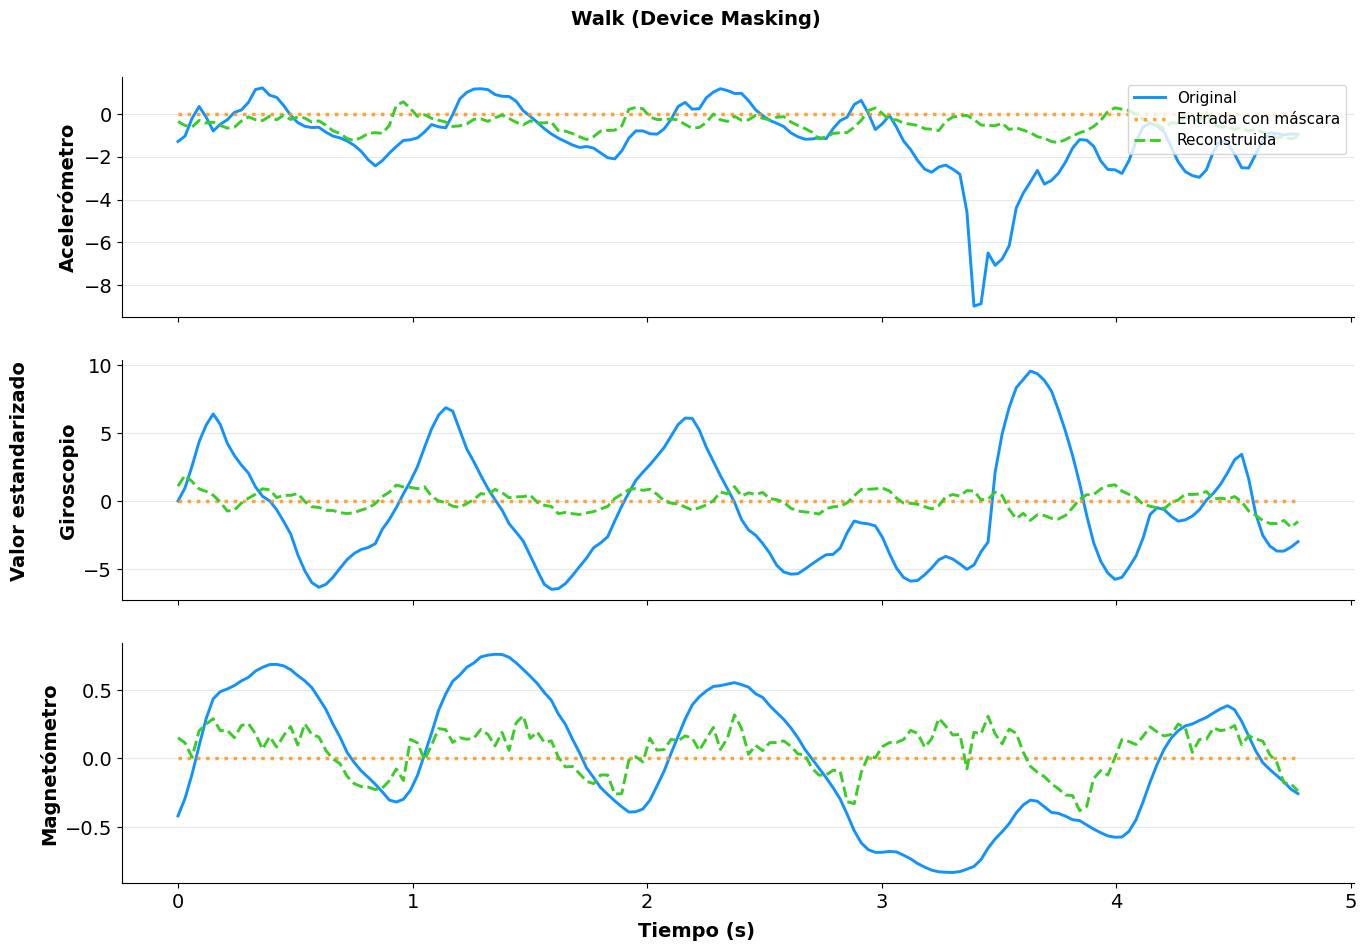

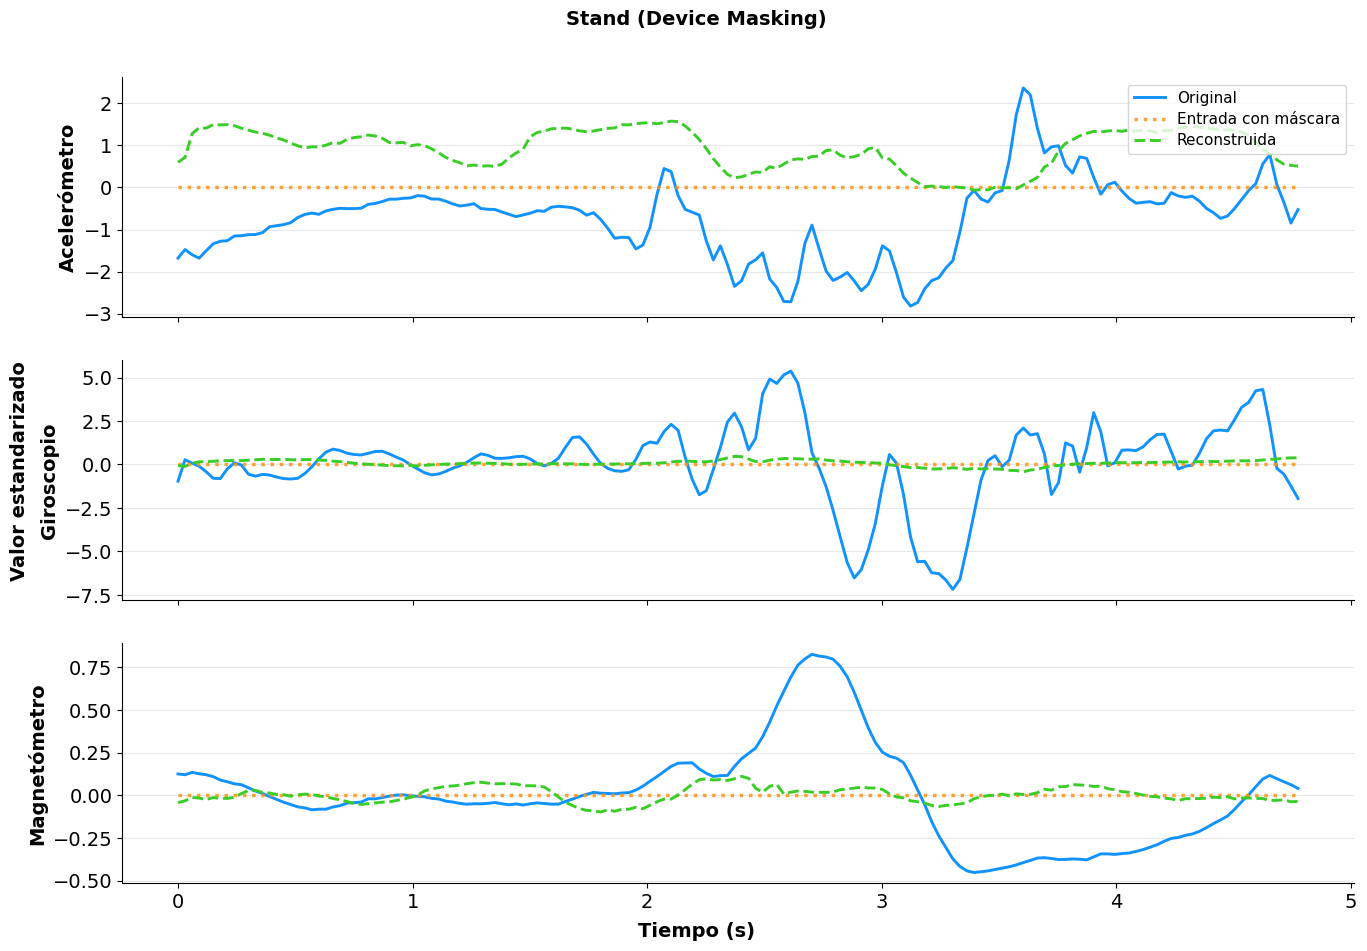

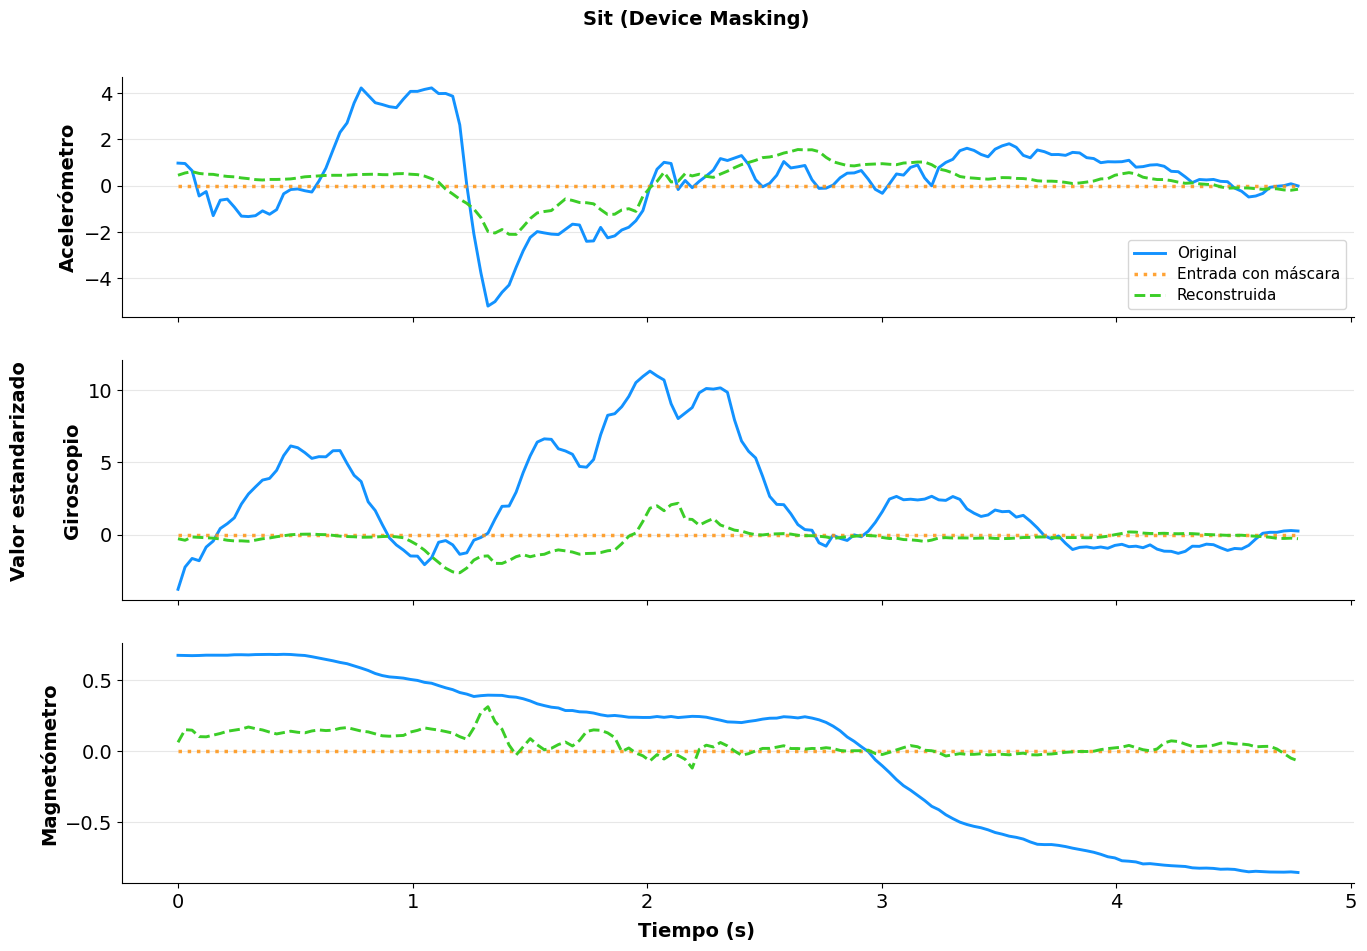

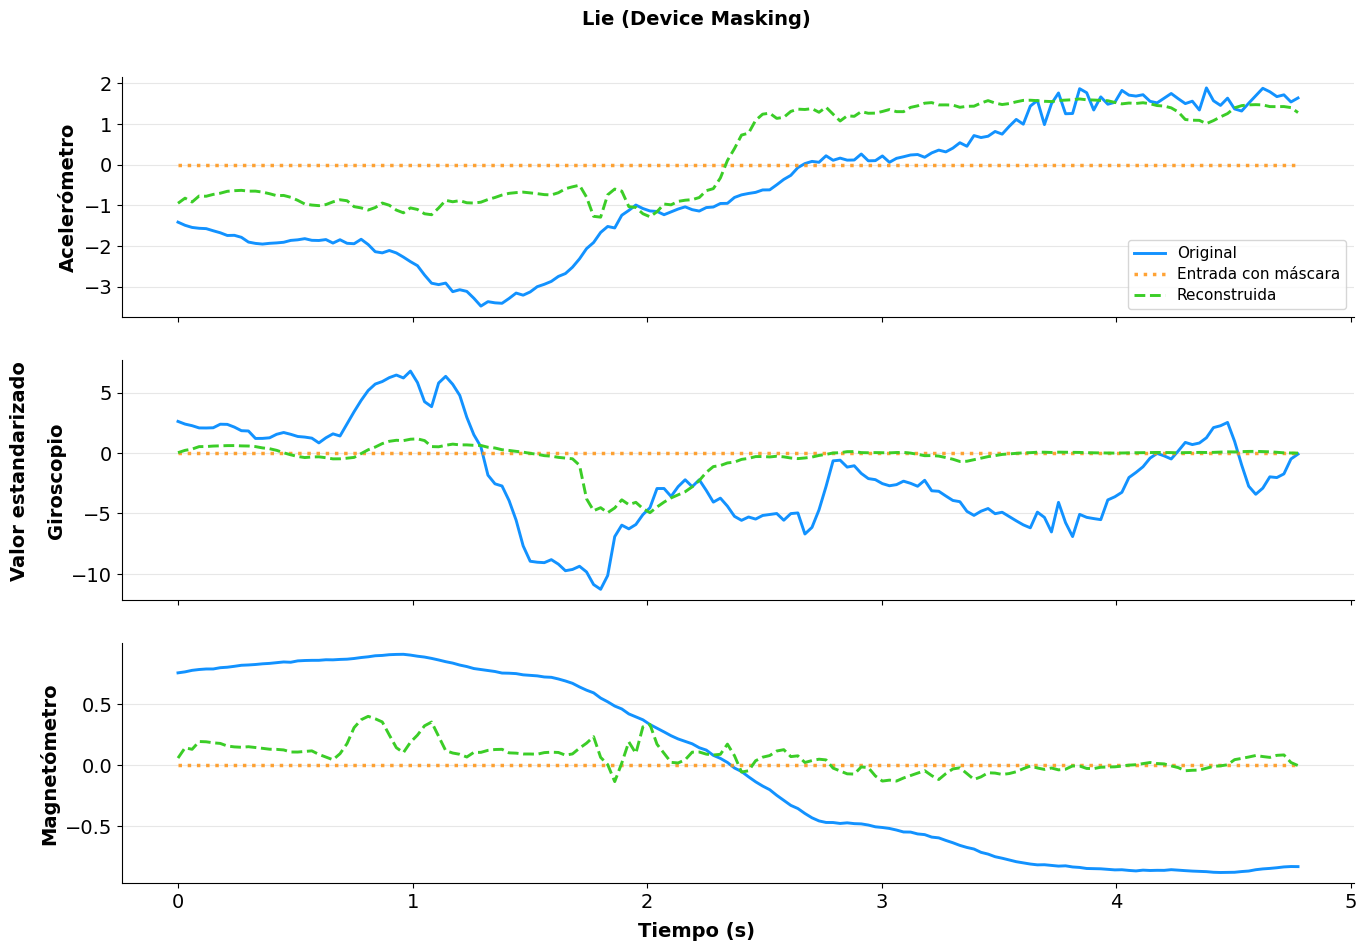

In [37]:
for activity in TARGET_ACTIVITIES:
    plot_reconstruction(activity)